In [1]:
# ======================================================================
# Cálculo GreenUR — muertes prematuras prevenibles por incremento de NDVI
# ======================================================================
#
# Este notebook calcula las muertes prematuras prevenibles asociadas con
# escenarios de aumento del NDVI en sectores censales con menor verdor.
#
# El cálculo se restringe a sectores censales con:
#
#     NDVI_2022_mean < P75
#
# Es decir, únicamente se estiman beneficios en sectores cuyo NDVI está
# por debajo del percentil 75 de la distribución.
#
# Los sectores con NDVI >= P75 permanecen en la base de resultados para
# trazabilidad, pero sus valores de incremento de NDVI, FAP y muertes
# prevenibles quedan en cero.
#
# IMPORTANTE:
# Para el resumen agregado, las muertes prevenibles se redondean primero
# a nivel de sector censal y después se suman.
#
# No se generan mapas en este notebook.
#
# ----------------------------------------------------------------------
# Variables requeridas en la base de entrada
# ----------------------------------------------------------------------
#
# La base debe estar en formato Excel y tener una fila por sector censal.
#
# 1. SETU_CCNCT
#    - Tipo esperado: texto
#    - Uso: identificador del sector censal.
#    - Sirve para unir los resultados con capas espaciales o bases externas.
#
# 2. NDVI_2022_mean
#    - Tipo esperado: numérico
#    - Uso: NDVI base del sector censal.
#
# 3. promedio_muertes_2015_2019_naturales_20_años
#    - Tipo esperado: numérico
#    - Uso: muertes esperadas base en población mayor de 20 años
#      por causas naturales.
#    - Debe estar en número de muertes, no en tasa.
#
# No se requiere geometría para este cálculo.

In [2]:
# ============================================================
# 1. Importar librerías y definir rutas
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Mostrar más columnas al revisar tablas dentro del notebook
pd.set_option("display.max_columns", 120)

# ------------------------------------------------------------
# Rutas de entrada y salida
# ------------------------------------------------------------

# Archivo de entrada.
# Debe estar en la misma carpeta del notebook.
# Si está en otra carpeta, cambiar esta ruta.
RUTA_ENTRADA = Path("METRO_GREENUR.xlsx")

# Carpeta donde se guardarán los resultados
CARPETA_SALIDA = Path("GREENUR_METRO")
CARPETA_SALIDA.mkdir(parents=True, exist_ok=True)

# Archivo Excel de salida
RUTA_SALIDA_EXCEL = CARPETA_SALIDA / "resultados_greenur_bajo_p75.xlsx"

# Archivo de figura
RUTA_SALIDA_FIGURA = CARPETA_SALIDA / "muertes_prevenibles_p75.png"

# ------------------------------------------------------------
# Nombres de columnas requeridas en la base
# ------------------------------------------------------------

COL_ID = "SETU_CCNCT"
COL_NDVI = "NDVI_2022_mean"
COL_MUERTES = "promedio_muertes_2015_2019_naturales_20_años"

COLUMNAS_REQUERIDAS = [
    COL_ID,
    COL_NDVI,
    COL_MUERTES
]

# ------------------------------------------------------------
# Parámetros del cálculo GreenUR
# ------------------------------------------------------------

# Percentil usado como umbral de intervención
PERCENTIL_NDVI = 0.75

# Escenarios de aumento proporcional del NDVI
# 0.05 = 5 %
# 0.10 = 10 %
ESCENARIOS_AUMENTO_NDVI = [0.05, 0.10]

# Hazard Ratio por aumento de 0,1 unidades de NDVI
HR_CENTRAL = 0.96
HR_LIMITE_INFERIOR = 0.94
HR_LIMITE_SUPERIOR = 0.97

In [3]:
# ============================================================
# 2. Funciones auxiliares
# ============================================================

def redondear_mitad_arriba(serie):
    """
    Redondea valores positivos usando el criterio tradicional:
    valores >= 0.5 suben al entero siguiente.

    Se usa para evitar el redondeo bancario de Python en casos .5.
    """

    return np.floor(serie + 0.5).astype(int)


def cargar_y_validar_base(
    ruta_entrada: Path,
    columnas_requeridas: list,
    col_id: str,
    col_ndvi: str,
    col_muertes: str
) -> pd.DataFrame:
    """
    Carga la base de entrada y valida que tenga las columnas necesarias.

    Parámetros
    ----------
    ruta_entrada : Path
        Ruta del archivo Excel de entrada.

    columnas_requeridas : list
        Lista de columnas que deben existir en la base.

    col_id : str
        Columna identificadora del sector censal.

    col_ndvi : str
        Columna con el NDVI base.

    col_muertes : str
        Columna con las muertes esperadas base.

    Retorna
    -------
    pd.DataFrame
        Base cargada y validada.
    """

    if not ruta_entrada.exists():
        raise FileNotFoundError(
            f"No se encontró el archivo de entrada: {ruta_entrada}. "
            "Revise que el archivo esté en la misma carpeta del notebook "
            "o ajuste la variable RUTA_ENTRADA."
        )

    # Leer archivo Excel
    df = pd.read_excel(ruta_entrada, dtype={col_id: str})

    # Limpiar nombres de columnas
    df.columns = df.columns.astype(str).str.strip()

    # Validar columnas requeridas
    faltantes = [col for col in columnas_requeridas if col not in df.columns]

    if faltantes:
        raise ValueError(
            "La base de entrada no tiene todas las columnas requeridas. "
            f"Faltan las siguientes columnas: {faltantes}"
        )

    # Asegurar que el identificador quede como texto
    df[col_id] = df[col_id].astype(str).str.strip()

    # Convertir variables numéricas
    for col in [col_ndvi, col_muertes]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # Validar datos faltantes o no numéricos
    faltantes_ndvi = df[col_ndvi].isna().sum()
    faltantes_muertes = df[col_muertes].isna().sum()

    if faltantes_ndvi > 0 or faltantes_muertes > 0:
        raise ValueError(
            "Hay valores faltantes o no numéricos en variables requeridas. "
            f"Faltantes en {col_ndvi}: {faltantes_ndvi}; "
            f"faltantes en {col_muertes}: {faltantes_muertes}."
        )

    # Validar rango general del NDVI
    if (df[col_ndvi] < -1).any() or (df[col_ndvi] > 1).any():
        print(
            "Advertencia: hay valores de NDVI por fuera del rango esperado "
            "[-1, 1]. Revise la base antes de interpretar los resultados."
        )

    # Validar muertes negativas
    if (df[col_muertes] < 0).any():
        raise ValueError(
            f"La columna {col_muertes} tiene valores negativos. "
            "Revise la base de entrada."
        )

    return df


def crear_diccionario_variables() -> pd.DataFrame:
    """
    Crea una tabla con la descripción de las variables mínimas de entrada.
    """

    df_diccionario = pd.DataFrame({
        "variable": [
            COL_ID,
            COL_NDVI,
            COL_MUERTES
        ],
        "tipo_esperado": [
            "texto",
            "numérico",
            "numérico"
        ],
        "descripcion": [
            "Identificador del sector censal. Permite unir resultados con capas espaciales o bases externas.",
            "NDVI base del sector censal. Se usa para calcular el percentil 75 y construir los escenarios de aumento.",
            "Muertes esperadas base en población mayor de 20 años por causas naturales. Debe estar en número de muertes, no en tasa."
        ]
    })

    return df_diccionario


def resumen_media_de(serie, decimales=2):
    """
    Devuelve texto tipo media (DE).
    """

    media = serie.mean()
    de = serie.std(ddof=1)

    return f"{media:.{decimales}f} ({de:.{decimales}f})"


def resumen_mediana_ric(serie, decimales=2):
    """
    Devuelve texto tipo mediana (RIC).
    RIC = Q1–Q3.
    """

    mediana = serie.median()
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)

    return f"{mediana:.{decimales}f} ({q1:.{decimales}f}–{q3:.{decimales}f})"


def resumen_min_max(serie, decimales=2):
    """
    Devuelve texto tipo mínimo–máximo.
    """

    minimo = serie.min()
    maximo = serie.max()

    return f"{minimo:.{decimales}f}–{maximo:.{decimales}f}"

In [4]:
# ============================================================
# 3. Función principal de cálculo GreenUR bajo P75
# ============================================================

def calcular_greenur_bajo_p75(
    df: pd.DataFrame,
    col_ndvi: str = COL_NDVI,
    col_muertes: str = COL_MUERTES,
    percentil_ndvi: float = PERCENTIL_NDVI,
    escenarios_aumento: list = ESCENARIOS_AUMENTO_NDVI,
    hr_central: float = HR_CENTRAL,
    hr_limite_inferior: float = HR_LIMITE_INFERIOR,
    hr_limite_superior: float = HR_LIMITE_SUPERIOR
):
    """
    Calcula escenarios GreenUR únicamente para sectores con NDVI < P75.

    Los sectores con NDVI >= P75 se mantienen en la base de salida,
    pero con incremento de NDVI, FAP y muertes prevenibles iguales a cero.

    IMPORTANTE:
    Las muertes prevenibles se redondean primero por sector censal.
    Luego se suman para obtener el total de cada escenario.

    Retorna
    -------
    df_out : pd.DataFrame
        Resultados por sector censal.

    df_resumen : pd.DataFrame
        Tabla resumen con las columnas solicitadas.

    df_grafico : pd.DataFrame
        Tabla auxiliar para graficar totales centrales e intervalo.
    """

    df_out = df.copy()

    # ------------------------------------------------------------
    # Calcular umbral P75 del NDVI
    # ------------------------------------------------------------

    ndvi_p75 = df_out[col_ndvi].quantile(percentil_ndvi)

    # Sectores intervenidos: solo NDVI < P75
    mascara_bajo_p75 = df_out[col_ndvi] < ndvi_p75

    df_out["NDVI_P75"] = ndvi_p75
    df_out["sector_bajo_P75"] = mascara_bajo_p75

    df_out["categoria_NDVI_P75"] = df_out["sector_bajo_P75"].map({
        True: "NDVI < P75",
        False: "NDVI >= P75"
    })

    # Muertes esperadas base usadas en el cálculo
    df_out["muertes_esperadas_base"] = df_out[col_muertes]

    # Listas para resultados agregados
    resumen = []
    resumen_grafico = []

    # ------------------------------------------------------------
    # Calcular cada escenario
    # ------------------------------------------------------------

    for aumento in escenarios_aumento:

        escenario = int(round(aumento * 100))
        sufijo = f"p75_{escenario}"

        col_incremento = f"incremento_NDVI_{sufijo}"
        col_ndvi_escenario = f"{col_ndvi}_escenario_{sufijo}"

        # --------------------------------------------------------
        # Incremento de NDVI
        # --------------------------------------------------------
        # Solo se aplica en sectores con NDVI < P75.

        df_out[col_incremento] = 0.0

        df_out.loc[mascara_bajo_p75, col_incremento] = (
            df_out.loc[mascara_bajo_p75, col_ndvi] * aumento
        )

        # NDVI del escenario
        df_out[col_ndvi_escenario] = (
            df_out[col_ndvi] + df_out[col_incremento]
        )

        # --------------------------------------------------------
        # Ajuste del HR según cambio de NDVI
        # --------------------------------------------------------
        # El HR está definido por cada aumento de 0,1 unidades de NDVI.
        # Por eso el incremento se divide entre 0,1.

        factor_cambio = df_out[col_incremento] / 0.1

        df_out[f"HR_{sufijo}"] = hr_central ** factor_cambio
        df_out[f"HR_hr_inferior_{sufijo}"] = hr_limite_inferior ** factor_cambio
        df_out[f"HR_hr_superior_{sufijo}"] = hr_limite_superior ** factor_cambio

        # --------------------------------------------------------
        # Fracción atribuible/prevenible — FAP
        # --------------------------------------------------------
        # El HR es protector, por eso se reporta la magnitud positiva.

        df_out[f"FAP_{sufijo}"] = (
            (df_out[f"HR_{sufijo}"] - 1) / df_out[f"HR_{sufijo}"]
        )

        df_out[f"FAP_hr_inferior_{sufijo}"] = (
            (df_out[f"HR_hr_inferior_{sufijo}"] - 1)
            / df_out[f"HR_hr_inferior_{sufijo}"]
        )

        df_out[f"FAP_hr_superior_{sufijo}"] = (
            (df_out[f"HR_hr_superior_{sufijo}"] - 1)
            / df_out[f"HR_hr_superior_{sufijo}"]
        )

        # --------------------------------------------------------
        # Muertes prematuras prevenibles sin redondear
        # --------------------------------------------------------

        df_out[f"muertes_prevenibles_{sufijo}"] = (
            df_out["muertes_esperadas_base"] * df_out[f"FAP_{sufijo}"].abs()
        )

        df_out[f"muertes_prevenibles_hr_inferior_{sufijo}"] = (
            df_out["muertes_esperadas_base"] * df_out[f"FAP_hr_inferior_{sufijo}"].abs()
        )

        df_out[f"muertes_prevenibles_hr_superior_{sufijo}"] = (
            df_out["muertes_esperadas_base"] * df_out[f"FAP_hr_superior_{sufijo}"].abs()
        )

        # --------------------------------------------------------
        # Redondeo por sector censal
        # --------------------------------------------------------
        # primero se redondea cada sector y después se suma.

        df_out[f"muertes_prevenibles_{sufijo}_redondeadas"] = redondear_mitad_arriba(
            df_out[f"muertes_prevenibles_{sufijo}"]
        )

        df_out[f"muertes_prevenibles_hr_inferior_{sufijo}_redondeadas"] = redondear_mitad_arriba(
            df_out[f"muertes_prevenibles_hr_inferior_{sufijo}"]
        )

        df_out[f"muertes_prevenibles_hr_superior_{sufijo}_redondeadas"] = redondear_mitad_arriba(
            df_out[f"muertes_prevenibles_hr_superior_{sufijo}"]
        )

        # --------------------------------------------------------
        # Datos solo de sectores intervenidos
        # --------------------------------------------------------
        # La tabla resumen se calcula sobre los sectores con NDVI < P75,
        # porque son los sectores donde se estiman beneficios.

        muertes_sector = df_out.loc[
            mascara_bajo_p75,
            f"muertes_prevenibles_{sufijo}_redondeadas"
        ]

        fap_sector = df_out.loc[
            mascara_bajo_p75,
            f"FAP_{sufijo}"
        ]

        # Totales del intervalo también después de redondear por sector
        total_hr_inferior = df_out.loc[
            mascara_bajo_p75,
            f"muertes_prevenibles_hr_inferior_{sufijo}_redondeadas"
        ].sum()

        total_hr_superior = df_out.loc[
            mascara_bajo_p75,
            f"muertes_prevenibles_hr_superior_{sufijo}_redondeadas"
        ].sum()

        total_central = muertes_sector.sum()

        total_low = min(total_hr_inferior, total_hr_superior)
        total_high = max(total_hr_inferior, total_hr_superior)

        # --------------------------------------------------------
        # Tabla resumen solicitada
        # --------------------------------------------------------

        resumen.append({
            "Escenario": f"{escenario}%",
            "Muertes (Total)": int(total_central),
            "Muertes Media (DE)": resumen_media_de(muertes_sector, decimales=2),
            "Muertes Mediana (RIC)": resumen_mediana_ric(muertes_sector, decimales=2),
            "Muertes Mín–Máx": resumen_min_max(muertes_sector, decimales=0),
            "FAP Media (DE)": resumen_media_de(fap_sector, decimales=4),
            "FAP Mediana (RIC)": resumen_mediana_ric(fap_sector, decimales=4),
            "FAP Mín–Máx": resumen_min_max(fap_sector, decimales=4)
        })

        # --------------------------------------------------------
        # Tabla auxiliar para gráfico
        # --------------------------------------------------------

        resumen_grafico.append({
            "Tipo": "q75",
            "Escenario (%)": escenario,
            "Central": int(total_central),
            "Low": int(total_low),
            "High": int(total_high),
            "NDVI_P75": ndvi_p75,
            "Sectores intervenidos": int(mascara_bajo_p75.sum())
        })

    df_resumen = pd.DataFrame(resumen)
    df_grafico = pd.DataFrame(resumen_grafico)

    return df_out, df_resumen, df_grafico

In [5]:
# ============================================================
# 4. Cargar base, ejecutar cálculo y revisar resultados
# ============================================================

# Cargar y validar la base de entrada
df = cargar_y_validar_base(
    ruta_entrada=RUTA_ENTRADA,
    columnas_requeridas=COLUMNAS_REQUERIDAS,
    col_id=COL_ID,
    col_ndvi=COL_NDVI,
    col_muertes=COL_MUERTES
)

print(f"Filas cargadas: {len(df):,}")
print(f"Columnas cargadas: {len(df.columns):,}")

# Ejecutar cálculo GreenUR bajo P75
df_resultados, df_resumen, df_grafico = calcular_greenur_bajo_p75(df)

# Mostrar tabla resumen
df_resumen

Filas cargadas: 110
Columnas cargadas: 6


,Escenario,Muertes (Total),Muertes Media (DE),Muertes Mediana (RIC),Muertes Mín–Máx,FAP Media (DE),FAP Mediana (RIC),FAP Mín–Máx
0,5%,3,0.04 (0.19),0.00 (0.00–0.00),0–1,-0.0042 (0.0006),-0.0041 (-0.0047–-0.0037),-0.0054–-0.0028
1,10%,23,0.28 (0.48),0.00 (0.00–1.00),0–2,-0.0084 (0.0013),-0.0082 (-0.0094–-0.0074),-0.0108–-0.0057


In [6]:
# ============================================================
# 5. Revisar tabla auxiliar para gráfico
# ============================================================

df_grafico

,Tipo,Escenario (%),Central,Low,High,NDVI_P75,Sectores intervenidos
0,q75,5,3,1,11,0.2638,82
1,q75,10,23,11,39,0.2638,82


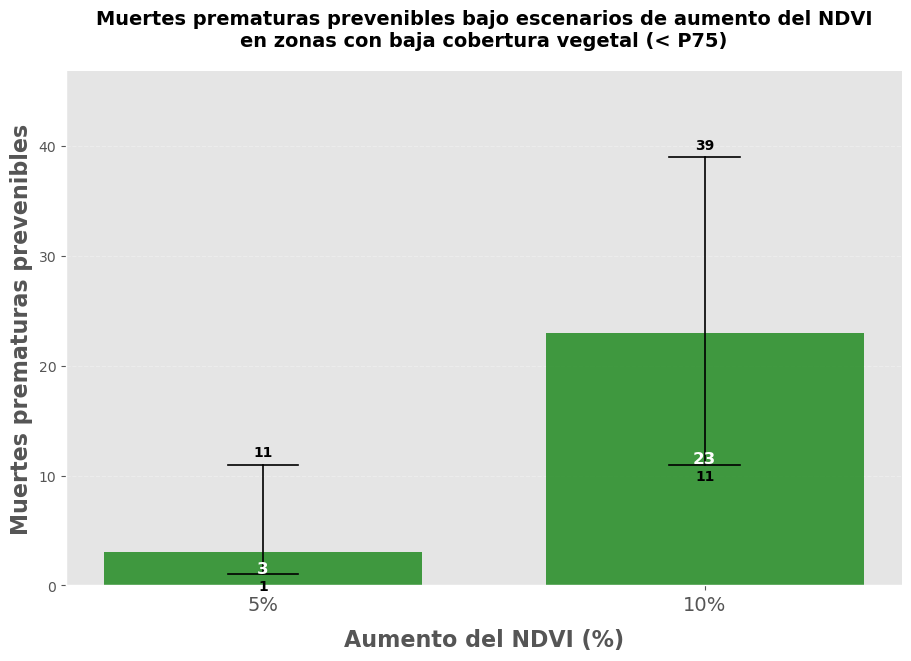

Figura guardada en: GREENUR_METRO/muertes_prevenibles_p75.png


In [7]:
# ============================================================
# 6. Gráfico de muertes prematuras prevenibles
# ============================================================

# Filtrar datos del escenario q75
sub = df_grafico[df_grafico["Tipo"] == "q75"].copy()

# Ordenar escenarios
sub = sub.sort_values("Escenario (%)")

# Configuración base
plt.style.use("ggplot")

fig, ax = plt.subplots(
    figsize=(9, 6.5),
    constrained_layout=True
)

# Posiciones
escenarios = sub["Escenario (%)"].tolist()
x = np.arange(len(escenarios))
width = 0.72

# Valores máximos para ajustar etiquetas proporcionalmente
y_max = sub["High"].max()
y_lim_superior = y_max * 1.2

# Barras
bars = ax.bar(
    x,
    sub["Central"],
    width,
    color="forestgreen",
    alpha=0.85
)

# Corchetes y etiquetas
for xi, low, high, central in zip(
    x,
    sub["Low"],
    sub["High"],
    sub["Central"]
):

    # Línea vertical del intervalo
    ax.plot(
        [xi, xi],
        [low, high],
        color="black",
        linewidth=1.2,
        zorder=3
    )

    # Corchete inferior
    ax.plot(
        [xi - 0.08, xi + 0.08],
        [low, low],
        color="black",
        linewidth=1.2,
        zorder=3
    )

    # Corchete superior
    ax.plot(
        [xi - 0.08, xi + 0.08],
        [high, high],
        color="black",
        linewidth=1.2,
        zorder=3
    )

    # Etiqueta central dentro de la barra
    ax.text(
        xi,
        central * 0.50,
        f"{central:,}",
        ha="center",
        va="center",
        color="white",
        fontsize=12,
        fontweight="bold"
    )

    # Etiqueta del límite inferior
    ax.text(
        xi,
        low - y_lim_superior * 0.01,
        f"{low:,}",
        ha="center",
        va="top",
        color="black",
        fontsize=10,
        fontweight="bold"
    )

    # Etiqueta del límite superior
    ax.text(
        xi,
        high + y_lim_superior * 0.01,
        f"{high:,}",
        ha="center",
        va="bottom",
        color="black",
        fontsize=10,
        fontweight="bold"
    )

# Ejes
ax.set_xticks(x)
ax.set_xticklabels(
    [f"{e}%" for e in escenarios],
    fontsize=14
)

ax.set_ylabel(
    "Muertes prematuras prevenibles",
    fontsize=16,
    weight="bold"
)

ax.set_xlabel(
    "Aumento del NDVI (%)",
    fontsize=16,
    weight="bold",
    labelpad=10
)

ax.set_title(
    "Muertes prematuras prevenibles bajo escenarios de aumento del NDVI\n"
    "en zonas con baja cobertura vegetal (< P75)",
    fontsize=14,
    weight="bold",
    pad=18
)

# Ajuste visual
ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.grid(axis="x", visible=False)

# Límites del eje Y
ax.set_ylim(0, y_lim_superior)

# Quitar bordes innecesarios
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Guardar figura
plt.savefig(
    RUTA_SALIDA_FIGURA,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Figura guardada en: {RUTA_SALIDA_FIGURA}")

In [8]:
# ============================================================
# 7. Exportar resultados
# ============================================================

# Diccionario de variables de entrada
df_diccionario = crear_diccionario_variables()

# Exportar en un solo archivo Excel con varias hojas
with pd.ExcelWriter(RUTA_SALIDA_EXCEL, engine="openpyxl") as writer:

    df_resultados.to_excel(
        writer,
        sheet_name="resultados_sector",
        index=False
    )

    df_resumen.to_excel(
        writer,
        sheet_name="resumen",
        index=False
    )

    df_grafico.to_excel(
        writer,
        sheet_name="resumen_grafico",
        index=False
    )

    df_diccionario.to_excel(
        writer,
        sheet_name="variables_requeridas",
        index=False
    )

print(f"Archivo exportado correctamente en: {RUTA_SALIDA_EXCEL}")

Archivo exportado correctamente en: GREENUR_METRO/resultados_greenur_bajo_p75.xlsx
